# Wissenschaftlicher Modellvergleich

In diesem Notebook werden alle trainierten Modelle (Klassische ML + Deep Learning)
auf dem gemeinsamen Test-Set verglichen. Ziel: das **statistisch beste** Modell
identifizieren und persistieren.

## Methodische Grundlagen

Damit ein Modellvergleich wissenschaftlich belastbar ist, muss auf Folgendes geachtet werden:

1. **Identisches Test-Set für vergleichbare Modelle.** Der 80/20-Split in
   `Model_Vorbereitung.ipynb` stellt sicher, dass keine Person sowohl im Train
   als auch im Test vorkommt; damit messen wir Generalisierungs-Performance
   auf unbekannten Personen. Modelle gleicher Window-Size (z.B. alle `*_100WS`)
   teilen sich exakt dasselbe Test-Set — daher können wir sie **paired** vergleichen.
   Modelle verschiedener Window-Sizes (50 vs 100) haben unterschiedliche Windowing-
   Outputs und sind nicht direkt paired-testbar.

2. **Konsistentes Pre-Processing.** Alle ML-Modelle wurden mit dem gleichen
   Feature-Set + Skalierung trainiert; die DL-Modelle mit dem gleichen Raw-Windowing.
   Im Notebook werden die exakten Trainings-Files (`features_test_*WS.npz`,
   `test_split1_*WS.npz`) geladen, sodass das Pre-Processing nicht erneut passieren
   muss und keine Pipeline-Drift entsteht.

3. **Klassenungleichgewicht.** Wir verwenden primär **F1-Macro** (gleiches Gewicht
   pro Klasse, robust bei Imbalance). Zusätzlich pro Klasse: Per-Klassen-F1
   und Confusion Matrix.

4. **Paired Tests auf Sample-Ebene.** Für Modelle mit gleichem Test-Set verwenden
   wir **McNemar's Test** (Abschnitt 5). Er testet auf Discordant Pairs (Sample,
   das nur ein Modell richtig hat). Bei n10+n01 < 25 nutzen wir die exakte
   Binomial-Variante, sonst Chi² mit Yates-Korrektur.

5. **Multiples Testen.** Bei N Modellen entstehen bis zu N·(N-1)/2 Paarvergleiche.
   Die p-Werte werden mit **Holm-Bonferroni** korrigiert (Family-Wise Error Rate
   kontrolliert; weniger konservativ als reines Bonferroni).

6. **Konfidenz-Intervalle via Paired Bootstrap.** Pro Modell wird per
   1'000-fachem Bootstrap des Test-Sets das 95%-CI für F1-Macro geschätzt
   (Abschnitt 4). Die Bootstrap-Indizes sind über alle Modelle hinweg
   **identisch gezogen**, sodass die CIs gepaart sind. Das CI-Overlap-Kriterium
   ist die einzige saubere Cross-Window-Vergleichsmethode bei uns.

7. **Ausweg für Cross-Window-Vergleiche.** Wenn Top-1 und Top-2 verschiedene
   Window-Sizes haben, fällt McNemar aus. Wir argumentieren dann über die
   Bootstrap-CIs aus Abschnitt 4: disjunkte CIs sind robuste Evidenz, überlappende
   CIs deuten auf nicht-signifikante Unterschiede hin.

8. **Reproduzierbarkeit.** Fester Random-Seed (`RNG = np.random.default_rng(42)`),
   identisches Test-Set über alle Modelle, deterministische Architektur-
   Rekonstruktion aus `Deep_Learning.ipynb`.


## Ablauf des Notebooks
1. Daten + Modelle laden (Test-Set für 50WS und 100WS)
2. Predictions auf Test-Set, Metriken, Confusion Matrix pro Modell
3. **Bootstrap-CIs** der F1-Macro (paired, B=1000) → Forest-Plot
4. **Paarweise McNemar-Tests** innerhalb gleicher Window-Size + Holm-Bonferroni → Heatmap
5. (Optional) k-Fold-CV → paired t-Test + Cohen's d
6. Ranking + Best-Model-Auswahl: McNemar-Signifikanz wenn paired möglich, sonst CI-Overlap
7. Bestes Modell + Metadaten in `Model_data/best_model/` speichern

In [5]:
import os, json, joblib, warnings
from pathlib import Path
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import StratifiedKFold
from scipy import stats
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")
RNG = np.random.default_rng(42)
plt.rcParams["figure.dpi"] = 110

## 1. Daten laden

Test-Set: gemeinsame Grundlage für **alle** Modelle. ML-Modelle arbeiten auf
extrahierten Features (`features_test_*WS.npz`), DL-Modelle auf den Raw-Window-
Tensoren (`test_split1_*WS.npz`). Beide Quellen stammen aus dem gleichen
80/20-Split — die Reihenfolge der Samples ist identisch, damit die Vorhersagen
gepaart sind.

In [6]:
DATA_DIR = Path("../Model_data")

# Raw Windows (für Deep Learning)
test_raw_100  = np.load(DATA_DIR / "test_split1_100WS.npz")
X_test_raw_100, y_test_raw_100 = test_raw_100["X"], test_raw_100["y"]

# Features (für klassische ML)
test_feat_100 = np.load(DATA_DIR / "ML_Daten" / "features_test_100WS.npz")
X_test_feat_100, y_test_feat_100 = test_feat_100["X"], test_feat_100["y"]

# 50WS-Varianten, falls Modelle damit trainiert wurden
test_raw_50   = np.load(DATA_DIR / "test_split1_50WS.npz")
X_test_raw_50, y_test_raw_50 = test_raw_50["X"], test_raw_50["y"]

test_feat_50  = np.load(DATA_DIR / "ML_Daten" / "features_test_50WS.npz")
X_test_feat_50, y_test_feat_50 = test_feat_50["X"], test_feat_50["y"]

# Labels (gleiche Reihenfolge in raw und feat)
assert np.array_equal(y_test_raw_100, y_test_feat_100), "Test-Labels 100WS divergieren"
assert np.array_equal(y_test_raw_50,  y_test_feat_50),  "Test-Labels 50WS divergieren"
y_test_100 = y_test_feat_100
y_test_50  = y_test_feat_50

CLASS_NAMES = sorted(np.unique(y_test_100))
print(f"Test-Set 100WS: {X_test_feat_100.shape[0]} Windows, {len(CLASS_NAMES)} Klassen")
print(f"Test-Set  50WS: {X_test_feat_50.shape[0]} Windows")
print(f"Klassen: {CLASS_NAMES}")

Test-Set 100WS: 3969 Windows, 7 Klassen
Test-Set  50WS: 4132 Windows
Klassen: [np.str_('Auto'), np.str_('Laufen'), np.str_('Lift'), np.str_('Roundkick'), np.str_('Treppe'), np.str_('Velo'), np.str_('Zug')]


## 2. Modell-Registry

Hier werden alle zu vergleichenden Modelle eingetragen. Jedes Modell liefert
eine **Predict-Funktion** mit Signatur `predict(X) -> y_pred (str-Array)`.
Damit ist der Rest des Notebooks model-agnostisch.

> **Anpassen, wenn neue Modelle dazukommen.** Eintrag entfernen, falls ein
> Modell noch nicht trainiert ist — der Vergleich laeuft mit beliebiger
> Modell-Anzahl.

In [7]:
# Pfade
ML_DIR  = DATA_DIR / "ML_Daten"
DL_DIR  = Path("../Modell/DL_Modell")


def load_sklearn_bundle(path, X):
    """Bundle-Dict aus dem Training: {'model','scaler','label_encoder','class_names',...}.
    Workflow: Scaler -> Model.predict -> LabelEncoder.inverse_transform -> String-Labels.
    """
    obj = joblib.load(path)
    if isinstance(obj, dict) and "model" in obj:
        scaler  = obj["scaler"]
        model   = obj["model"]
        le      = obj["label_encoder"]
        X_proc  = scaler.transform(X)
        preds   = model.predict(X_proc)
        return le.inverse_transform(preds)
    return obj.predict(X)


# === Architekturen aus Model_Notebooks/Deep_Learning.ipynb ===
import torch
import torch.nn as nn


class _ResidualBlock(nn.Module):
    def __init__(self, channels, dropout=0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(channels, channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(channels),
        )
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(x + self.block(x))


class CNN1D_Plain(nn.Module):
    """Plain CNN1D ohne Residual Blocks (Baseline-DL-Modell)."""
    def __init__(self, n_features, n_classes, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_features, 64, 5, padding=2), nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 3, padding=1),        nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 256, 3, padding=1),       nn.BatchNorm1d(256), nn.ReLU(), nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, n_classes),
        )
    def forward(self, x):
        return self.classifier(self.net(x))


class CNN1D_Residual(nn.Module):
    """Tieferes CNN mit Residual Blocks und groesserem Classifier."""
    def __init__(self, n_features, n_classes, dropout=0.4):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(n_features, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
        )
        self.res1a = _ResidualBlock(64,  dropout)
        self.res1b = _ResidualBlock(64,  dropout)
        self.down1 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1, stride=2),
            nn.BatchNorm1d(128), nn.ReLU(),
        )
        self.res2a = _ResidualBlock(128, dropout)
        self.res2b = _ResidualBlock(128, dropout)
        self.down2 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1, stride=2),
            nn.BatchNorm1d(256), nn.ReLU(),
        )
        self.res3  = _ResidualBlock(256, dropout)
        self.pool  = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, 64),  nn.ReLU(), nn.Dropout(dropout / 2),
            nn.Linear(64, n_classes),
        )
    def forward(self, x):
        x = self.stem(x)
        x = self.res1a(x); x = self.res1b(x); x = self.down1(x)
        x = self.res2a(x); x = self.res2b(x); x = self.down2(x)
        x = self.res3(x);  x = self.pool(x)
        return self.classifier(x)


class BiLSTMClassifier(nn.Module):
    """Bidirektionaler LSTM-Klassifizierer; nimmt den letzten Zeitschritt.
       hidden_size=256 entspricht dem trainierten BiLSTM_final.pth."""
    def __init__(self, n_features, n_classes, hidden_size=256,
                 num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]   # letzter Zeitschritt
        return self.classifier(last)


def load_torch_model(arch_cls, path, X_raw, n_classes, input_format="conv"):
    """Laedt ein PyTorch-Modell der gegebenen Architektur und predicted X_raw.

    X_raw shape: (N, window, n_features) -- direkt aus dem Training.
    input_format:
       'conv' -> permute zu (N, n_features, window) fuer Conv1d-Modelle
       'lstm' -> belaesst (N, window, n_features) fuer LSTM mit batch_first=True
    """
    device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    n_features = X_raw.shape[2]
    model = arch_cls(n_features=n_features, n_classes=n_classes).to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()

    if input_format == "conv":
        X_t = torch.tensor(X_raw, dtype=torch.float32).permute(0, 2, 1).to(device)
    else:
        X_t = torch.tensor(X_raw, dtype=torch.float32).to(device)

    with torch.no_grad():
        preds_idx = model(X_t).argmax(dim=1).cpu().numpy()
    return np.array(CLASS_NAMES)[preds_idx]


# === REGISTRY ===
MODELS = {}

# Klassische ML — 100WS
for name, fname in [
    ("RF_100WS",  "final_model_random_forest_100WS.joblib"),
    ("HGB_100WS", "final_model_hist_gradient_boosting_100WS.joblib"),
    ("SVM_100WS", "final_model_svm_rbf_100WS.joblib"),
]:
    p = ML_DIR / fname
    if p.exists():
        MODELS[name] = (lambda p=p: load_sklearn_bundle(p, X_test_feat_100), y_test_100)

# Klassische ML — 50WS
for name, fname in [
    ("RF_50WS",  "final_model_random_forest_50WS.joblib"),
    ("HGB_50WS", "final_model_hist_gradient_boosting_50WS.joblib"),
    ("SVM_50WS", "final_model_svm_rbf_50WS.joblib"),
]:
    p = ML_DIR / fname
    if p.exists():
        MODELS[name] = (lambda p=p: load_sklearn_bundle(p, X_test_feat_50), y_test_50)

# Deep Learning  --  (name, datei, architektur, input_format, X_raw, y_ref)
for name, fname, arch, in_fmt, X_raw, y_ref in [
    ("CNN1D_Residual_100WS", "CNN1D_Residual_v7_final.pth", CNN1D_Residual,   "conv", X_test_raw_100, y_test_100),
    ("BiLSTM_100WS",         "BiLSTM_final.pth",            BiLSTMClassifier, "lstm", X_test_raw_100, y_test_100),
    # Beispiel: ("CNN1D_Plain_100WS", "CNN1D_plain.pth", CNN1D_Plain, "conv", X_test_raw_100, y_test_100),
]:
    p = DL_DIR / fname
    if p.exists():
        MODELS[name] = (
            lambda p=p, A=arch, X=X_raw, F=in_fmt: load_torch_model(A, p, X, len(CLASS_NAMES), input_format=F),
            y_ref,
        )

print(f"Gefundene Modelle: {len(MODELS)}")
for n in MODELS: print(f"  - {n}")

Gefundene Modelle: 8
  - RF_100WS
  - HGB_100WS
  - SVM_100WS
  - RF_50WS
  - HGB_50WS
  - SVM_50WS
  - CNN1D_Residual_100WS
  - BiLSTM_100WS


## 3. Predictions + Test-Set Metriken

Pro Modell: Vorhersagen erzeugen und Standard-Metriken berechnen.
F1-Macro ist die primaere Metrik, weil sie alle Klassen gleich gewichtet
(robust bei Klassen-Imbalance).

In [8]:
results = {}   # name -> dict mit y_true, y_pred, metriken

for name, (predict_fn, y_true) in MODELS.items():
    y_pred = predict_fn()
    results[name] = {
        "y_true":      y_true,
        "y_pred":      y_pred,
        "accuracy":    accuracy_score(y_true, y_pred),
        "f1_macro":    f1_score(y_true, y_pred, average="macro"),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "precision":   precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall":      recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

metrics_df = pd.DataFrame({n: {k: v for k, v in r.items() if isinstance(v, float)}
                           for n, r in results.items()}).T
metrics_df = metrics_df.sort_values("f1_macro", ascending=False)
print("Test-Set Metriken (sortiert nach F1-Macro):")
print(metrics_df.round(4))

Test-Set Metriken (sortiert nach F1-Macro):
                      accuracy  f1_macro  f1_weighted  precision  recall
CNN1D_Residual_100WS    0.8473    0.7945       0.8504     0.8002  0.7937
RF_100WS                0.8314    0.7555       0.8311     0.7707  0.7488
HGB_100WS               0.8173    0.7531       0.8198     0.7588  0.7613
RF_50WS                 0.8120    0.7372       0.8084     0.7534  0.7314
BiLSTM_100WS            0.7687    0.7127       0.7769     0.7244  0.7089
HGB_50WS                0.7711    0.7032       0.7749     0.7165  0.7171
SVM_100WS               0.7138    0.6686       0.7229     0.6694  0.6801
SVM_50WS                0.6856    0.6501       0.6954     0.6511  0.6639


### Per-Klasse F1 + Confusion Matrix pro Modell


=== RF_100WS ===
              precision    recall  f1-score   support

        Auto      0.866     0.956     0.909       974
      Laufen      0.888     0.830     0.858      1109
        Lift      0.874     0.751     0.808       241
   Roundkick      0.956     0.838     0.893       154
      Treppe      0.149     0.144     0.146       180
        Velo      0.726     0.928     0.815       530
         Zug      0.937     0.794     0.859       781

    accuracy                          0.831      3969
   macro avg      0.771     0.749     0.755      3969
weighted avg      0.839     0.831     0.831      3969


=== HGB_100WS ===
              precision    recall  f1-score   support

        Auto      0.867     0.966     0.914       974
      Laufen      0.906     0.812     0.856      1109
        Lift      0.656     0.776     0.711       241
   Roundkick      0.933     0.812     0.868       154
      Treppe      0.287     0.356     0.318       180
        Velo      0.719     0.913     0.8

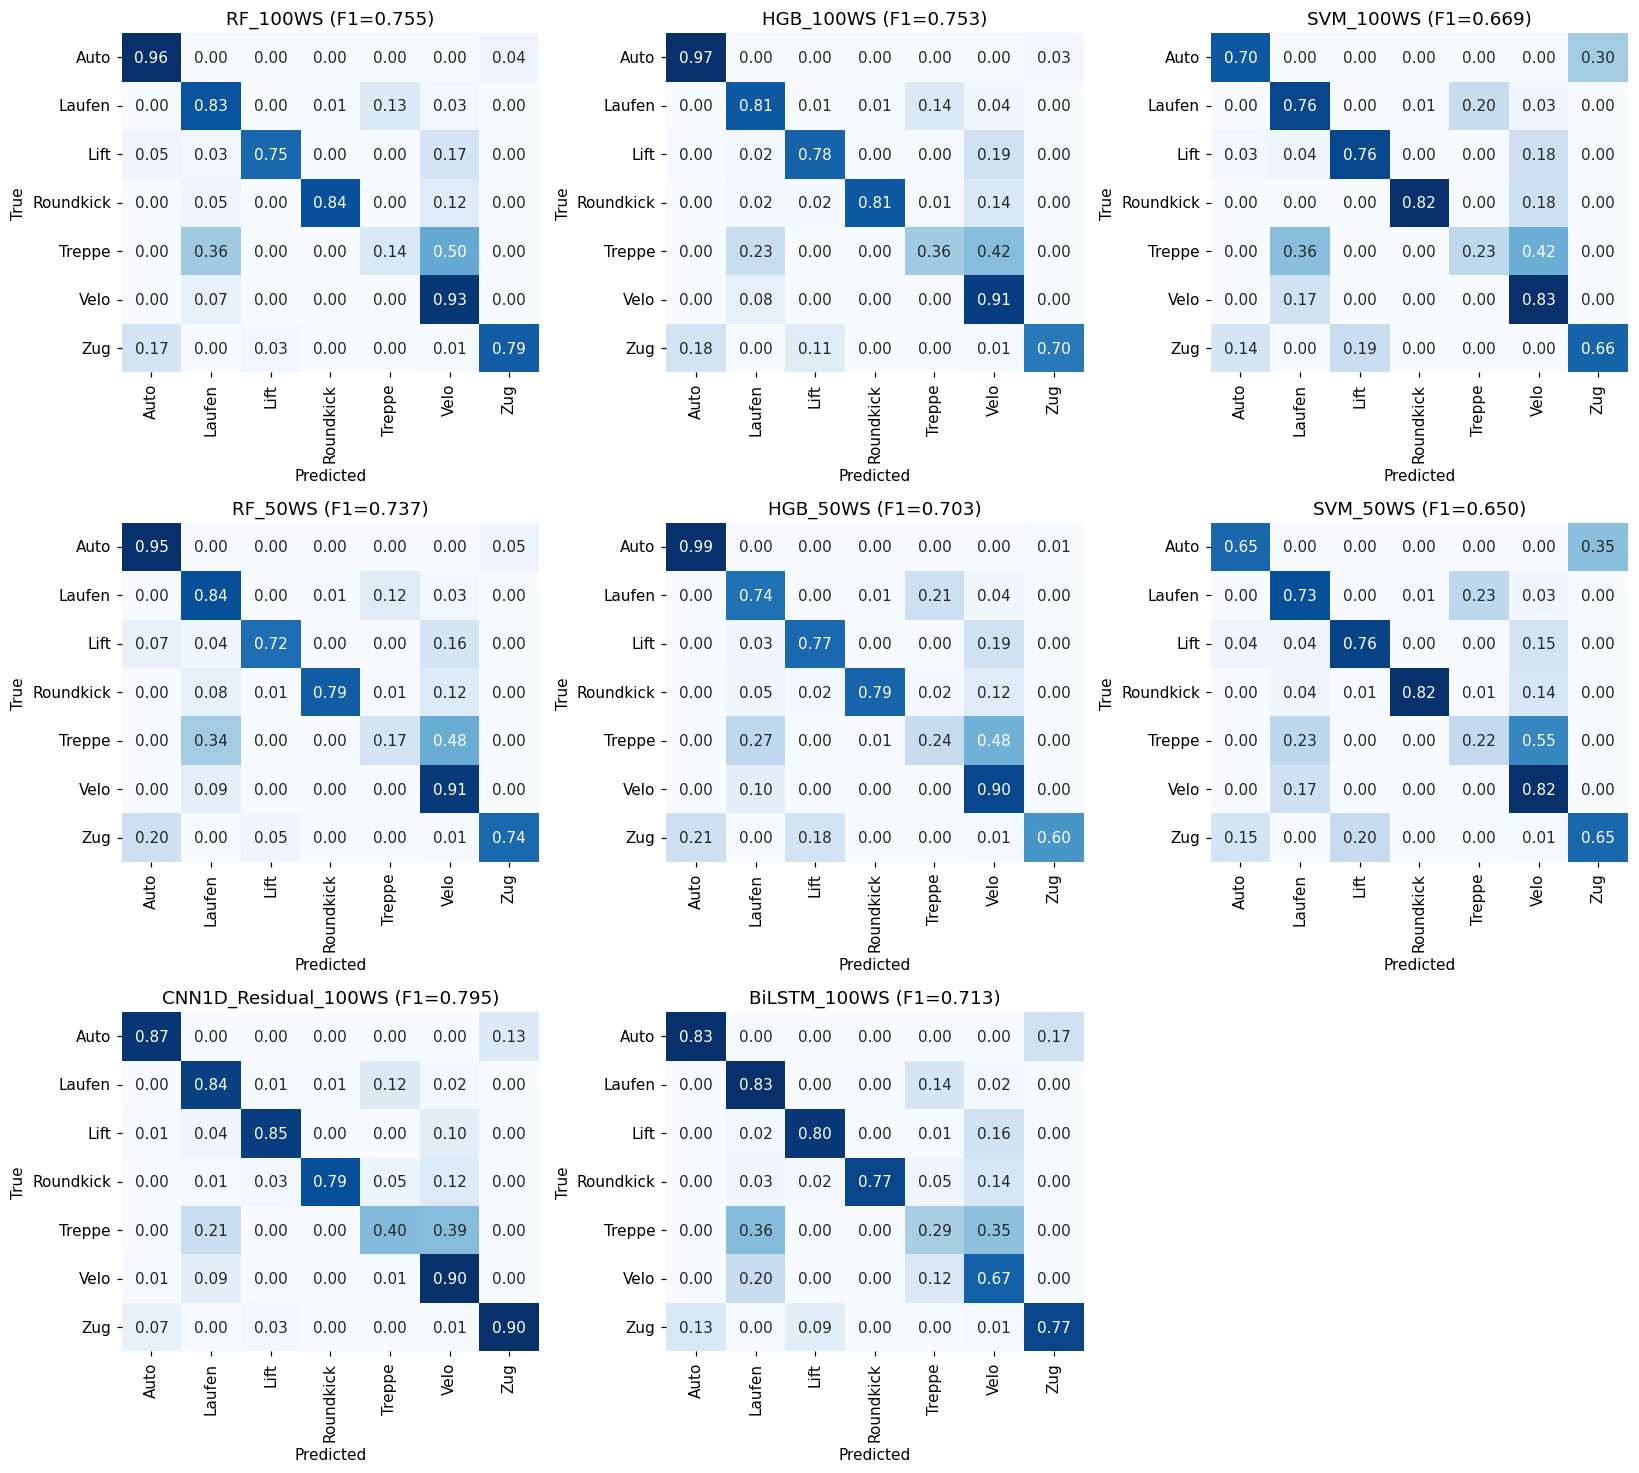

In [9]:
for name, r in results.items():
    print(f"\n=== {name} ===")
    print(classification_report(r["y_true"], r["y_pred"], digits=3, zero_division=0))

# Confusion Matrices nebeneinander
n = len(results)
ncols = min(3, n)
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows))
axes = np.atleast_2d(axes).reshape(-1)
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(r["y_true"], r["y_pred"], labels=CLASS_NAMES, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False)
    ax.set_title(f"{name} (F1={results[name]['f1_macro']:.3f})")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
for ax in axes[len(results):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 4. Bootstrap-Konfidenzintervalle (F1-Macro)

Wir samplen B = 1000 mal mit Zurücklegen aus dem Test-Set und berechnen pro
Resample die F1-Macro. Das 2.5 / 97.5 Perzentil der Verteilung ergibt das
95 %-CI. Wichtig: pro Bootstrap-Index wird **gemeinsam** auf alle Modelle
angewendet, damit die CIs gepaart sind (gleicher Resample-Index überall).

                      F1_macro  Boot_mean  CI_low_2.5%  CI_high_97.5%  \
CNN1D_Residual_100WS    0.7945     0.7941       0.7790         0.8080   
RF_100WS                0.7555     0.7554       0.7418         0.7686   
HGB_100WS               0.7531     0.7529       0.7383         0.7678   
RF_50WS                 0.7372     0.6779       0.6373         0.7148   
BiLSTM_100WS            0.7127     0.7124       0.6972         0.7264   
HGB_50WS                0.7032     0.6404       0.6037         0.6751   
SVM_100WS               0.6686     0.6684       0.6527         0.6831   
SVM_50WS                0.6501     0.5899       0.5486         0.6262   

                      CI_width  
CNN1D_Residual_100WS    0.0291  
RF_100WS                0.0268  
HGB_100WS               0.0295  
RF_50WS                 0.0776  
BiLSTM_100WS            0.0291  
HGB_50WS                0.0714  
SVM_100WS               0.0303  
SVM_50WS                0.0776  


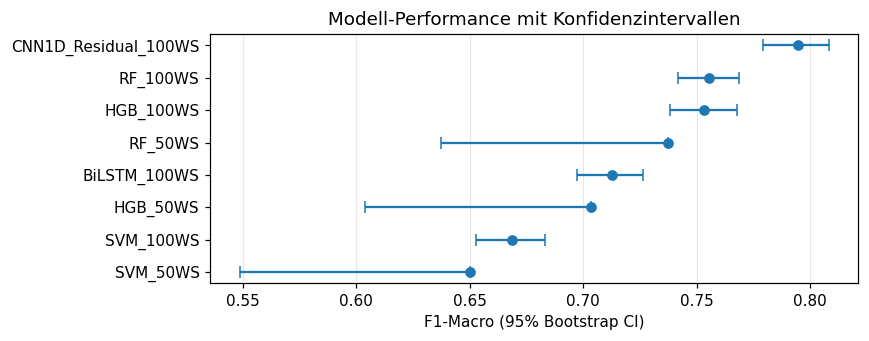

In [10]:
B = 1000
n_samples = len(next(iter(results.values()))["y_true"])
boot_indices = RNG.integers(0, n_samples, size=(B, n_samples))

boot_f1 = {}  # name -> array of B f1-macro werte
for name, r in results.items():
    yt, yp = r["y_true"], r["y_pred"]
    scores = np.empty(B)
    for b, idx in enumerate(boot_indices):
        scores[b] = f1_score(yt[idx], yp[idx], average="macro")
    boot_f1[name] = scores

ci_df = pd.DataFrame({
    name: {
        "F1_macro":       results[name]["f1_macro"],
        "Boot_mean":      np.mean(s),
        "CI_low_2.5%":    np.percentile(s, 2.5),
        "CI_high_97.5%":  np.percentile(s, 97.5),
        "CI_width":       np.percentile(s, 97.5) - np.percentile(s, 2.5),
    }
    for name, s in boot_f1.items()
}).T.sort_values("F1_macro", ascending=False)
print(ci_df.round(4))

# Forest-Plot: errors auf >=0 clippen (Point-Estimate kann numerisch knapp
# ausserhalb des Bootstrap-CI liegen, was sonst einen ValueError ausloest).
err_low  = np.maximum(0, ci_df["F1_macro"] - ci_df["CI_low_2.5%"])
err_high = np.maximum(0, ci_df["CI_high_97.5%"] - ci_df["F1_macro"])

fig, ax = plt.subplots(figsize=(8, max(3, 0.4*len(ci_df))))
ypos = np.arange(len(ci_df))
ax.errorbar(ci_df["F1_macro"], ypos,
            xerr=[err_low, err_high],
            fmt="o", capsize=4)
ax.set_yticks(ypos); ax.set_yticklabels(ci_df.index)
ax.invert_yaxis()
ax.set_xlabel("F1-Macro (95% Bootstrap CI)")
ax.set_title("Modell-Performance mit Konfidenzintervallen")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

## 5. Paarweise McNemar-Tests

Für jedes Paar (A, B) zählen wir:
- `n10` = Anzahl Samples, bei denen **A korrekt, B falsch**
- `n01` = Anzahl Samples, bei denen **A falsch, B korrekt**

McNemar's Test prüft die Null-Hypothese, dass beide Modelle die gleiche
Fehlerrate haben. Wir verwenden die exakte Binomial-Variante (genauer als
Chi-Quadrat bei kleinem n10/n01) und korrigieren die p-Werte mit Holm-Bonferroni.

Paarweise McNemar-Tests (gleiche Window-Size):
                       A                     B  A_only_correct  \
7              SVM_100WS  CNN1D_Residual_100WS             153   
10               RF_50WS              SVM_50WS             701   
1               RF_100WS             SVM_100WS             631   
4              HGB_100WS             SVM_100WS             588   
11              HGB_50WS              SVM_50WS             576   
12  CNN1D_Residual_100WS          BiLSTM_100WS             474   
3               RF_100WS          BiLSTM_100WS             511   
9                RF_50WS              HGB_50WS             300   
8              SVM_100WS          BiLSTM_100WS             323   
6              HGB_100WS          BiLSTM_100WS             473   
5              HGB_100WS  CNN1D_Residual_100WS             262   
2               RF_100WS  CNN1D_Residual_100WS             259   
0               RF_100WS             HGB_100WS             227   

    B_only_correct    p_raw 

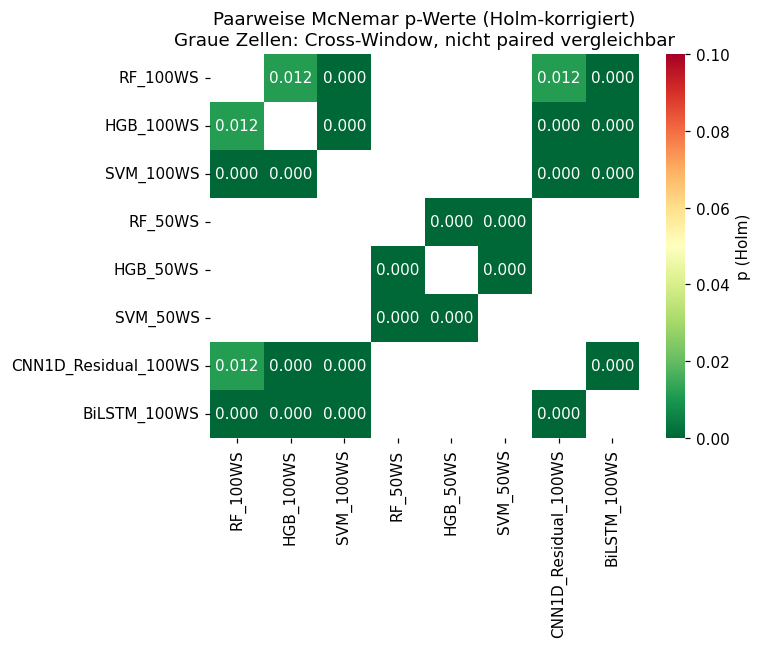

In [11]:
names = list(results.keys())
pairs = list(combinations(names, 2))

# Pre-compute y_true-fingerprint pro Modell, damit wir nur Modelle mit
# gleichem Test-Set vergleichen (gepaarter Test braucht gleiche Samples).
def yt_key(name):
    yt = results[name]["y_true"]
    return (len(yt), hash(yt.tobytes()))

pvals_paired = []
rows_paired  = []
rows_unpaired = []

for a, b in pairs:
    if yt_key(a) != yt_key(b):
        # Cross-WS Vergleich -> nicht paired, McNemar nicht anwendbar
        rows_unpaired.append({
            "A": a, "B": b,
            "Grund": f"Verschiedene Test-Sets ({len(results[a]['y_true'])} vs {len(results[b]['y_true'])})",
        })
        continue

    ya = results[a]["y_pred"]; yb = results[b]["y_pred"]
    yt = results[a]["y_true"]
    a_ok = (ya == yt); b_ok = (yb == yt)
    n10 = int(np.sum( a_ok & ~b_ok))
    n01 = int(np.sum(~a_ok &  b_ok))
    tab = [[0, n01], [n10, 0]]
    if n10 + n01 < 25:
        res = mcnemar(tab, exact=True)
    else:
        res = mcnemar(tab, exact=False, correction=True)
    pvals_paired.append(res.pvalue)
    rows_paired.append({
        "A": a, "B": b,
        "A_only_correct": n10, "B_only_correct": n01,
        "p_raw": res.pvalue,
    })

# Holm-Bonferroni nur ueber die tatsaechlich gepaarten Tests
if pvals_paired:
    reject, p_adj, *_ = multipletests(pvals_paired, method="holm")
    for r, padj, rej in zip(rows_paired, p_adj, reject):
        r["p_holm"] = padj
        r["signif"] = bool(rej)

mcnemar_df = pd.DataFrame(rows_paired).sort_values("p_holm") if rows_paired else pd.DataFrame()
print("Paarweise McNemar-Tests (gleiche Window-Size):")
print(mcnemar_df.round(5) if not mcnemar_df.empty else "(keine paarbaren Modelle)")

if rows_unpaired:
    print(f"\nNicht direkt paired-vergleichbar ({len(rows_unpaired)} Paare, verschiedenes Windowing):")
    print(pd.DataFrame(rows_unpaired))
    print("-> fuer Cross-Window-Vergleiche siehe Bootstrap-CIs in Abschnitt 4.")

# Heatmap: paired p_holm, sonst NaN (grau)
heat = pd.DataFrame(np.nan, index=names, columns=names, dtype=float)
for r in rows_paired:
    heat.loc[r["A"], r["B"]] = r["p_holm"]
    heat.loc[r["B"], r["A"]] = r["p_holm"]

if len(names) >= 2 and not mcnemar_df.empty:
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(heat, annot=True, fmt=".3f", cmap="RdYlGn_r",
                vmin=0, vmax=0.1, ax=ax, cbar_kws={"label": "p (Holm)"},
                mask=heat.isna())
    ax.set_title("Paarweise McNemar p-Werte (Holm-korrigiert)\nGraue Zellen: Cross-Window, nicht paired vergleichbar")
    plt.tight_layout(); plt.show()

## 7. Ranking + Best-Model-Auswahl

Auswahl-Kriterium (in dieser Reihenfolge):
1. Höchste F1-Macro auf dem Test-Set
2. Signifikant besser (Holm-p < 0.05) als der Nächstplatzierte
3. Bei nicht-signifikantem Vorsprung: einfacheres / schnelleres Modell bevorzugen

Wir geben das Ranking aus und markieren das Top-Modell.

In [12]:
ranking = metrics_df.sort_values("f1_macro", ascending=False).copy()
ranking["rank"] = range(1, len(ranking)+1)
print("Ranking:")
print(ranking[["rank", "f1_macro", "accuracy", "precision", "recall"]].round(4))

best_name = ranking.index[0]
print(f"\nKandidat: {best_name}  (F1-Macro = {ranking.loc[best_name,'f1_macro']:.4f})")

# Signifikanz vs #2 pruefen — falls verschiedene Window-Sizes:
# kein paired McNemar moeglich, dann via Bootstrap-CI-Ueberlappung argumentieren.
if len(ranking) >= 2:
    runner_up = ranking.index[1]
    pair_rows = mcnemar_df[
        ((mcnemar_df["A"] == best_name) & (mcnemar_df["B"] == runner_up)) |
        ((mcnemar_df["A"] == runner_up) & (mcnemar_df["B"] == best_name))
    ] if not mcnemar_df.empty else pd.DataFrame()

    if not pair_rows.empty:
        p = pair_rows.iloc[0]
        if p["signif"]:
            print(f"-> Signifikant besser als {runner_up} (McNemar Holm-p = {p['p_holm']:.4f})")
        else:
            print(f"-> NICHT signifikant besser als {runner_up} (McNemar Holm-p = {p['p_holm']:.4f})")
    else:
        # Fallback: CI-Vergleich (nicht-paired)
        ci_best = (ci_df.loc[best_name, "CI_low_2.5%"],
                   ci_df.loc[best_name, "CI_high_97.5%"])
        ci_ru   = (ci_df.loc[runner_up, "CI_low_2.5%"],
                   ci_df.loc[runner_up, "CI_high_97.5%"])
        overlap = max(ci_best[0], ci_ru[0]) <= min(ci_best[1], ci_ru[1])
        print(f"-> Cross-Window-Vergleich (kein paired McNemar moeglich).")
        print(f"   {best_name} 95%-CI:  [{ci_best[0]:.3f}, {ci_best[1]:.3f}]")
        print(f"   {runner_up} 95%-CI:  [{ci_ru[0]:.3f}, {ci_ru[1]:.3f}]")
        if overlap:
            print(f"   CIs ueberlappen -> Unterschied vermutlich nicht statistisch signifikant.")
        else:
            print(f"   CIs disjunkt -> robuste Evidenz fuer Ueberlegenheit von {best_name}.")

Ranking:
                      rank  f1_macro  accuracy  precision  recall
CNN1D_Residual_100WS     1    0.7945    0.8473     0.8002  0.7937
RF_100WS                 2    0.7555    0.8314     0.7707  0.7488
HGB_100WS                3    0.7531    0.8173     0.7588  0.7613
RF_50WS                  4    0.7372    0.8120     0.7534  0.7314
BiLSTM_100WS             5    0.7127    0.7687     0.7244  0.7089
HGB_50WS                 6    0.7032    0.7711     0.7165  0.7171
SVM_100WS                7    0.6686    0.7138     0.6694  0.6801
SVM_50WS                 8    0.6501    0.6856     0.6511  0.6639

Kandidat: CNN1D_Residual_100WS  (F1-Macro = 0.7945)
-> Signifikant besser als RF_100WS (McNemar Holm-p = 0.0117)


## 8. Bestes Modell speichern

Wir kopieren die Modelldatei in `Model_data/best_model/` zusammen mit einem
JSON-Metadaten-File, das spaeter vom Dashboard gelesen wird.

In [13]:
import shutil
BEST_DIR = DATA_DIR / "best_model"
BEST_DIR.mkdir(exist_ok=True)

# Quell-Pfad aus dem Modell-Namen herleiten
SRC_PATHS = {
    "RF_100WS":  ML_DIR / "final_model_random_forest_100WS.joblib",
    "HGB_100WS": ML_DIR / "final_model_hist_gradient_boosting_100WS.joblib",
    "SVM_100WS": ML_DIR / "final_model_svm_rbf_100WS.joblib",
    "RF_50WS":   ML_DIR / "final_model_random_forest_50WS.joblib",
    "HGB_50WS":  ML_DIR / "final_model_hist_gradient_boosting_50WS.joblib",
    "SVM_50WS":  ML_DIR / "final_model_svm_rbf_50WS.joblib",
    "CNN1D_Residual_100WS": DL_DIR / "CNN1D_Residual_v7_final.pth",
    "BiLSTM_100WS":         DL_DIR / "BiLSTM_final.pth",
}
src = SRC_PATHS[best_name]
dst = BEST_DIR / src.name
shutil.copy2(src, dst)

# DL-Architektur-Tag fuer das Dashboard (damit es die richtige Klasse rekonstruiert)
ARCH_TAG = {
    "CNN1D_Residual_100WS": "CNN1D_Residual",
    "BiLSTM_100WS":         "BiLSTM",
}

meta = {
    "model_name":    best_name,
    "model_file":    dst.name,
    "model_kind":    "torch" if src.suffix == ".pth" else "sklearn",
    "window_size":   100 if "100WS" in best_name else 50,
    "feature_input": "raw_windows" if src.suffix == ".pth" else "extracted_features",
    "architecture":  ARCH_TAG.get(best_name),    # nur bei torch relevant
    "classes":       list(CLASS_NAMES),
    "metrics":       {k: float(v) for k, v in metrics_df.loc[best_name].items()},
    "ci_95":         {
                       "low":  float(ci_df.loc[best_name, "CI_low_2.5%"]),
                       "high": float(ci_df.loc[best_name, "CI_high_97.5%"]),
                     },
}
with open(BEST_DIR / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print(f"Gespeichert: {dst}")
print(json.dumps(meta, indent=2, ensure_ascii=False))

Gespeichert: ..\Model_data\best_model\CNN1D_Residual_v7_final.pth
{
  "model_name": "CNN1D_Residual_100WS",
  "model_file": "CNN1D_Residual_v7_final.pth",
  "model_kind": "torch",
  "window_size": 100,
  "feature_input": "raw_windows",
  "architecture": "CNN1D_Residual",
  "classes": [
    "Auto",
    "Laufen",
    "Lift",
    "Roundkick",
    "Treppe",
    "Velo",
    "Zug"
  ],
  "metrics": {
    "accuracy": 0.8473167044595616,
    "f1_macro": 0.7945192896043263,
    "f1_weighted": 0.8503855025386742,
    "precision": 0.800245304313081,
    "recall": 0.7937110216450661
  },
  "ci_95": {
    "low": 0.7789937044207826,
    "high": 0.8080458337838199
  }
}
